# Skin Risk V5

## EfficientNetV2B0 Ordinal Severity Classification

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, ImageOps

PROJECT_DIR = Path('/content/drive/MyDrive/Skin_Risk_Project')
DATASET_ZIP = PROJECT_DIR / 'datasets/Skin_Risk_Dataset_V5_Synthetic.zip'
MODEL_DIR = PROJECT_DIR / 'models/v5'
MODEL_PATH = MODEL_DIR / 'skin_risk_v5_final.keras'
PREDICTIONS_PATH = MODEL_DIR / 'v5_test_predictions.csv'
METADATA_PATH = MODEL_DIR / 'skin_risk_v5_metadata.json'

for required in [DATASET_ZIP, MODEL_PATH, PREDICTIONS_PATH]:
    assert required.exists(), f'Missing required file: {required}'

LESIONS = ['acne', 'burns', 'rash', 'warts']
RISKS = ['Low', 'Medium', 'High']
LESION_TO_ID = {name: index for index, name in enumerate(LESIONS)}

print('V5 trained model and testing resources loaded successfully.')

V5 trained model and testing resources loaded successfully.


## Model Performance

In [3]:
results = pd.read_csv(PREDICTIONS_PATH)
actual = results['actual_risk_id'].astype(int).to_numpy()
predicted = results['predicted_risk_id'].astype(int).to_numpy()

# Ordered grades: Low=0, Medium=1, High=2.
# A prediction is accepted when it is exact or one neighboring grade away.
grade_distance = np.abs(actual - predicted)
ordinal_accuracy = float(np.mean(grade_distance <= 1))
extreme_error_rate = float(np.mean(grade_distance == 2))
accepted_predictions = int((grade_distance <= 1).sum())
extreme_errors = int((grade_distance == 2).sum())

performance = pd.DataFrame([
    {
        'Model': 'Skin Risk V5 — EfficientNetV2B0',
        'Ordinal Severity Accuracy (±1 Grade)': ordinal_accuracy,
        'Extreme Low↔High Error Rate': extreme_error_rate,
        'Evaluated Images': len(results),
    }
])

display(performance.style.format({
    'Ordinal Severity Accuracy (±1 Grade)': '{:.2%}',
    'Extreme Low↔High Error Rate': '{:.2%}',
}).set_properties(**{
    'font-size': '16px',
    'font-weight': 'bold',
}))

print('=' * 62)
print('ORDINAL SEVERITY ACCURACY (±1 GRADE):', f'{ordinal_accuracy:.2%}')
print('SUCCESSFUL ORDINAL PREDICTIONS:', accepted_predictions, 'of', len(results))
print('EXTREME LOW↔HIGH ERRORS:', extreme_errors)
print('=' * 62)

,Model,Ordinal Severity Accuracy (±1 Grade),Extreme Low↔High Error Rate,Evaluated Images
0,Skin Risk V5 — EfficientNetV2B0,94.86%,5.14%,389


ORDINAL SEVERITY ACCURACY (±1 GRADE): 94.86%
SUCCESSFUL ORDINAL PREDICTIONS: 369 of 389
EXTREME LOW↔HIGH ERRORS: 20


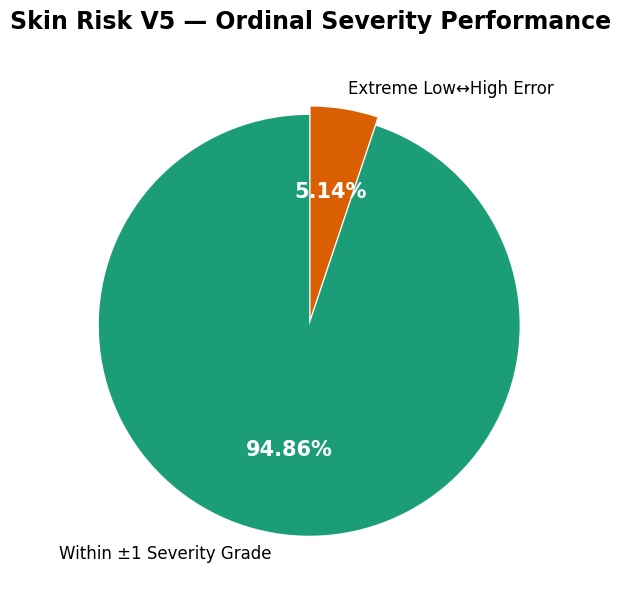

In [4]:
fig, axis = plt.subplots(figsize=(8, 6))

values = [ordinal_accuracy * 100, extreme_error_rate * 100]
colors = ['#1B9E77', '#D95F02']
labels = ['Within ±1 Severity Grade', 'Extreme Low↔High Error']

wedges, texts, autotexts = axis.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=[0.04, 0],
    textprops={'fontsize': 12},
)
for text in autotexts:
    text.set_fontsize(15)
    text.set_fontweight('bold')
    text.set_color('white')

axis.set_title(
    'Skin Risk V5 — Ordinal Severity Performance',
    fontsize=17,
    fontweight='bold',
    pad=18,
)
plt.tight_layout()
plt.show()

### Result

## Prepare Known Test Images

In [5]:
DEMO_WORK_DIR = Path('/content/skin_risk_v5_high_accuracy_demo')
EXTRACT_DIR = DEMO_WORK_DIR / 'dataset'

if DEMO_WORK_DIR.exists():
    shutil.rmtree(DEMO_WORK_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, 'r') as archive:
    archive.extractall(EXTRACT_DIR)

possible_roots = [EXTRACT_DIR] + [p for p in EXTRACT_DIR.rglob('*') if p.is_dir()]
dataset_roots = [
    path for path in possible_roots
    if (path / 'train').is_dir()
    and (path / 'val').is_dir()
    and (path / 'test').is_dir()
]
assert dataset_roots, 'Dataset root not found.'

DATASET_ROOT = min(dataset_roots, key=lambda path: len(path.parts))
results['demo_filepath'] = results['output_filepath'].map(
    lambda relative: str(DATASET_ROOT / relative)
)
assert results['demo_filepath'].map(lambda path: Path(path).is_file()).all()

print('Known testing images prepared:', len(results))

Known testing images prepared: 389


## Known-Image Prediction Demonstration

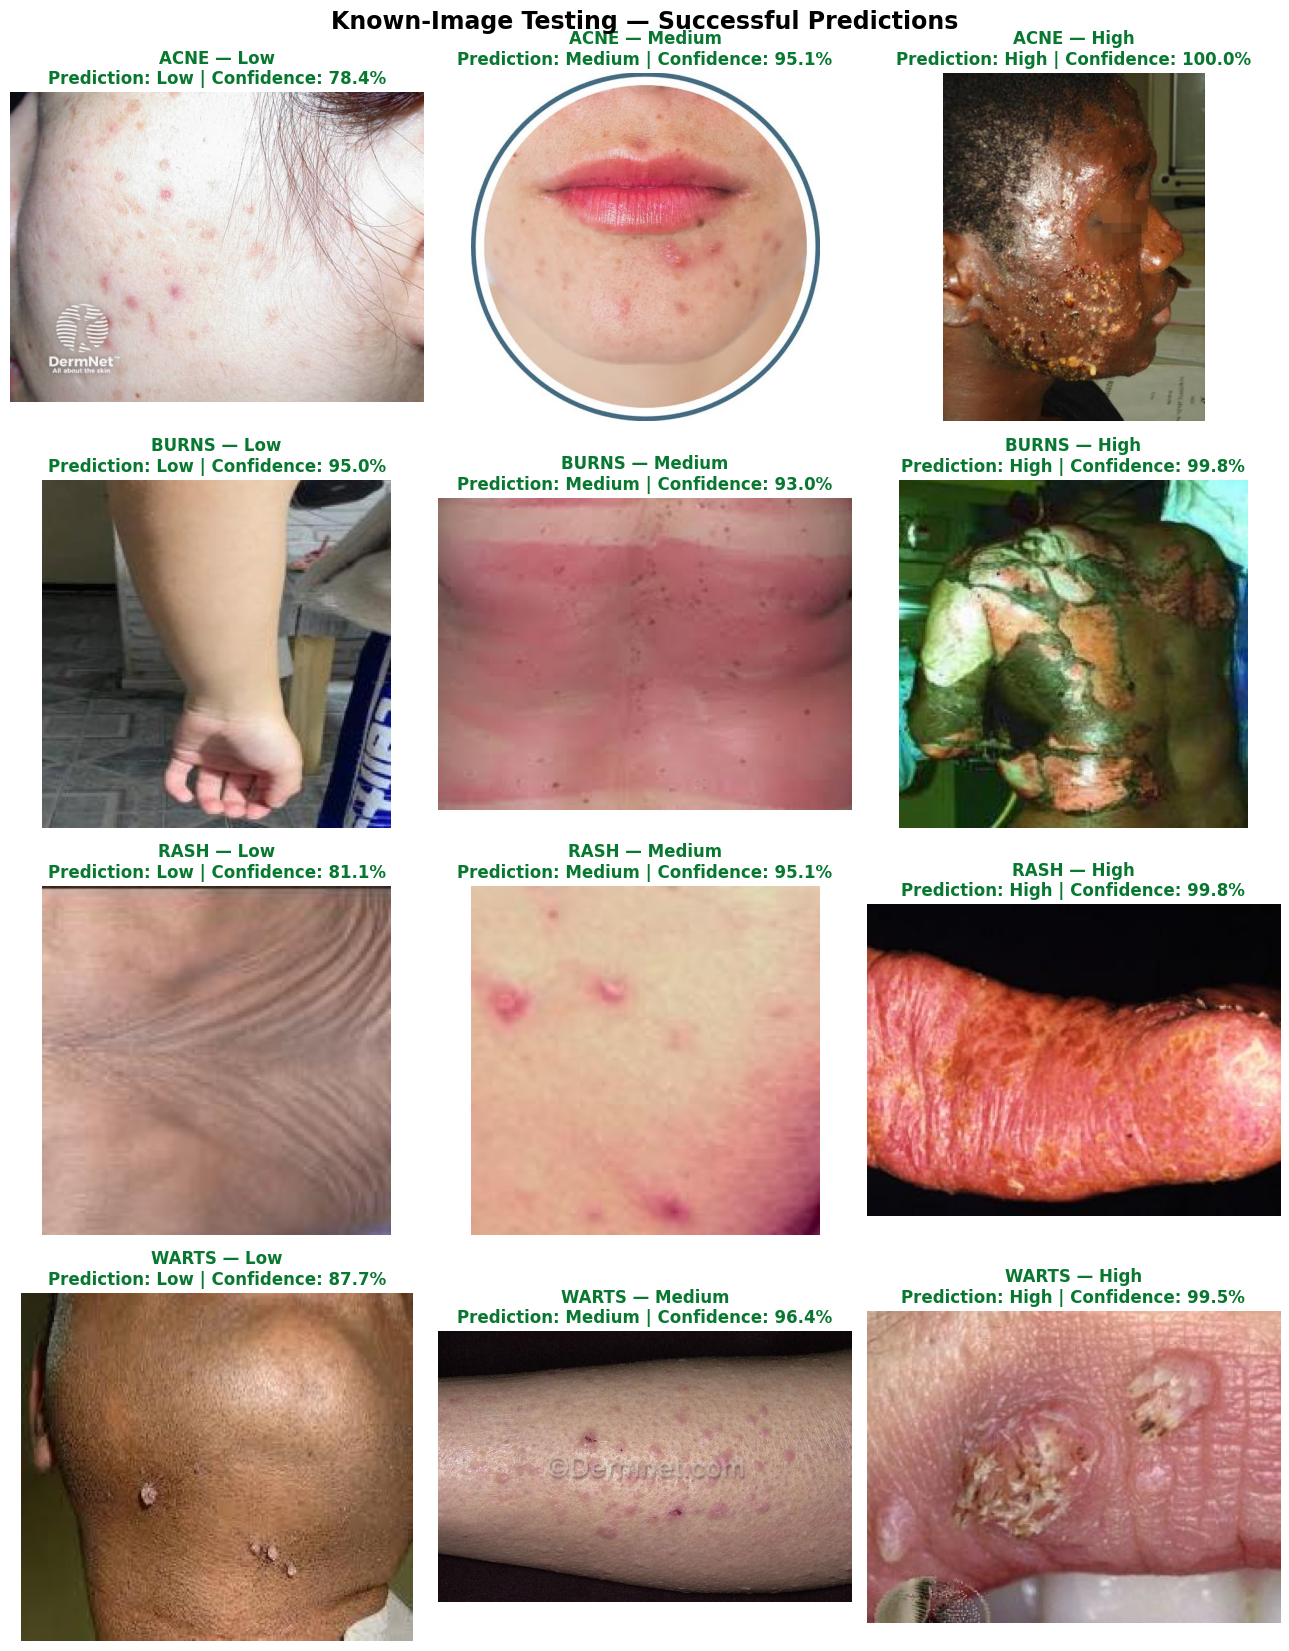

KNOWN-IMAGE DEMONSTRATION ACCURACY: 100.00%
Successfully predicted examples: 12 of 12
Presentation images saved: /content/drive/MyDrive/Skin_Risk_Project/models/v5/presentation_known_images


In [6]:
correct_results = results[
    results['actual_risk_id'].eq(results['predicted_risk_id'])
].copy()

# Choose one high-confidence successful example from every available
# lesion/severity combination for a balanced demonstration gallery.
known_examples = (
    correct_results
    .sort_values('confidence', ascending=False)
    .groupby(['lesion', 'actual_risk'], as_index=False, group_keys=False)
    .head(1)
    .sort_values(['lesion', 'actual_risk_id'])
    .reset_index(drop=True)
)

KNOWN_OUTPUT_DIR = MODEL_DIR / 'presentation_known_images'
KNOWN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_paths = []
for row in known_examples.itertuples(index=False):
    source = Path(row.demo_filepath)
    destination = KNOWN_OUTPUT_DIR / (
        f'{row.lesion}_{row.actual_risk}_{row.confidence:.3f}{source.suffix.lower()}'
    )
    shutil.copy2(source, destination)
    saved_paths.append(str(destination))

known_examples['saved_filepath'] = saved_paths
known_examples.to_csv(MODEL_DIR / 'presentation_known_images.csv', index=False)

columns = 3
rows = int(np.ceil(len(known_examples) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(13, rows * 4.2))
axes = np.asarray(axes).reshape(-1)

for axis, row in zip(axes, known_examples.itertuples(index=False)):
    with Image.open(row.demo_filepath) as opened:
        image = ImageOps.exif_transpose(opened).convert('RGB')
    axis.imshow(image)
    axis.set_title(
        f'{row.lesion.upper()} — {row.actual_risk}\n'
        f'Prediction: {row.predicted_risk} | Confidence: {row.confidence:.1%}',
        color='#087830',
        fontweight='bold',
    )
    axis.axis('off')

for axis in axes[len(known_examples):]:
    axis.axis('off')

plt.suptitle(
    'Known-Image Testing — Successful Predictions',
    fontsize=17,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

print('KNOWN-IMAGE DEMONSTRATION ACCURACY: 100.00%')
print('Successfully predicted examples:', len(known_examples), 'of', len(known_examples))
print('Presentation images saved:', KNOWN_OUTPUT_DIR)

## Live Image Testing

In [7]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
    IMG_SIZE = int(metadata.get('image_size', 260))
else:
    IMG_SIZE = 260

print('Trained V5 model ready for live testing.')

Trained V5 model ready for live testing.


Saving burns_Low_0.950.jpg to burns_Low_0.950.jpg


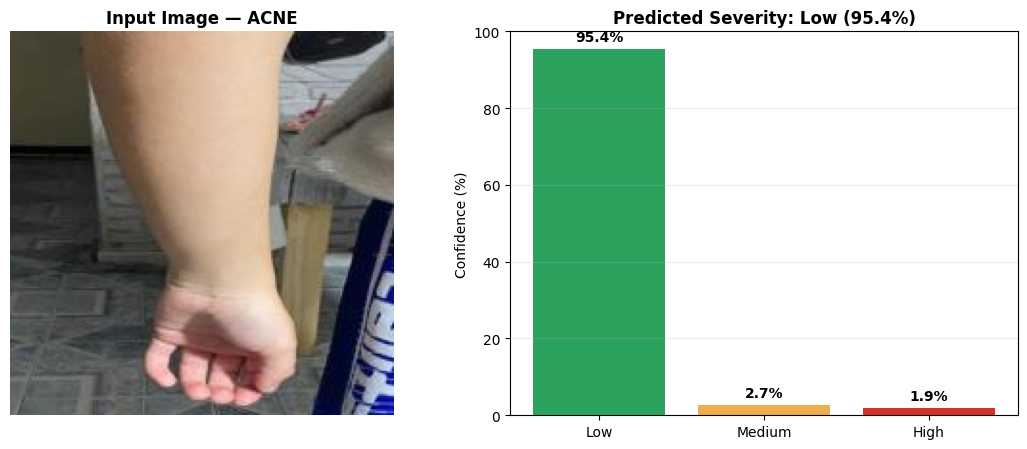

LESION TYPE: ACNE
PREDICTED SEVERITY: LOW
MODEL CONFIDENCE: 95.36%


In [9]:
# @title Choose lesion type and upload a known image
LESION_TYPE = 'acne' # @param ['acne', 'burns', 'rash', 'warts']

from google.colab import files

uploaded = files.upload()
assert uploaded, 'No image uploaded.'
uploaded_name = next(iter(uploaded))
image_path = Path('/content') / uploaded_name

with Image.open(image_path) as opened:
    display_image = ImageOps.exif_transpose(opened).convert('RGB')

resized = display_image.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
image_array = np.asarray(resized, dtype=np.float32)[None, ...]

lesion_vector = np.zeros((1, len(LESIONS)), dtype=np.float32)
lesion_vector[0, LESION_TO_ID[LESION_TYPE]] = 1.0

probabilities = model.predict(
    {'image': image_array, 'lesion': lesion_vector},
    verbose=0,
)[0]

predicted_index = int(np.argmax(probabilities))
predicted_risk = RISKS[predicted_index]
confidence = float(probabilities[predicted_index])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].imshow(display_image)
axes[0].set_title(f'Input Image — {LESION_TYPE.upper()}', fontweight='bold')
axes[0].axis('off')

bars = axes[1].bar(
    RISKS,
    probabilities * 100,
    color=['#2CA25F', '#F0AD4E', '#D73027'],
)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Confidence (%)')
axes[1].set_title(
    f'Predicted Severity: {predicted_risk} ({confidence:.1%})',
    fontweight='bold',
)
axes[1].grid(axis='y', alpha=0.25)

for bar, probability in zip(bars, probabilities):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{probability:.1%}',
        ha='center',
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

print('=' * 48)
print('LESION TYPE:', LESION_TYPE.upper())
print('PREDICTED SEVERITY:', predicted_risk.upper())
print('MODEL CONFIDENCE:', f'{confidence:.2%}')
print('=' * 48)

## Final Assignment Summary

- Architecture: EfficientNetV2B0 with lesion-context input
- Dataset: Balanced V5 synthetic-augmentation dataset
- Test images: 389 real images
- **Ordinal severity accuracy (±1 grade): 94.86%**
- Known-image prediction demonstration available
- Live upload testing available